In [6]:
import nltk
from matplotlib import pyplot as plt
from nltk.corpus import stopwords
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
import pandas as pd

from events_data_core.plot_utils import plot_2d

nltk.download('stopwords')
russian_stopwords = stopwords.words("russian")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
def find_optimal_k(X, K: range = range(2, 200), plot_results=True):
    K = list(K)
    inertias = []
    silhouettes = []

    for k in K:
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)
        score = silhouette_score(X, labels)
        silhouettes.append(score)
        print(f"k={k}: inertia={model.inertia_:.0f}, silhouette={score:.3f}")

    # Визуализация
    if plot_results:
        plot_2d(list(K), inertias, "Количество кластеров (k)", "Inertia", "Метод локтя")
        plot_2d(list(K), silhouettes, "Количество кластеров (k)", "Silhouette Score", "Silhouette")

    best_silhouette = max((s for s in silhouettes if not pd.isna(s)), default=None)
    best_k = K[silhouettes.index(best_silhouette)] if best_silhouette is not None else None
    best_inertia = inertias[K.index(best_k)] if best_k is not None else None
    return {
        "best_k": best_k,
        "best_silhouette": best_silhouette,
        "best_inertia": best_inertia,
        "inertias": inertias,
        "silhouettes": silhouettes,
        "k_values": K,
    }


def test_tfidf_configs(texts, vectorizer_params_list, K=range(2, 50)):
    """
    Перебирает разные конфигурации TfidfVectorizer,
    вызывает find_optimal_k() для каждой и рисует
    два итоговых графика: Inertia и Silhouette Score.
    """
    all_results = []

    for params in vectorizer_params_list:
        print(f"\n🔹 TF-IDF параметры: {params}")

        # 1️⃣ Векторизация текста
        vectorizer = TfidfVectorizer(**params)
        X = vectorizer.fit_transform(texts)

        # 2️⃣ Используем твою функцию find_optimal_k
        res = find_optimal_k(X, K, plot_results=False)
        all_results.append({
            "params": params,
            "inertias": res["inertias"],
            "silhouettes": res["silhouettes"],
            "k_values": list(res["k_values"]),
            "best_k": res["best_k"],
            "best_silhouette": res["best_silhouette"]
        })

    # 3️⃣ Общие графики сравнения
    plt.figure(figsize=(12, 5))

    # --- Inertia ---
    plt.subplot(1, 2, 1)
    for r in all_results:
        plt.plot(r["k_values"], r["inertias"], marker='o', label=str(r["params"]))
    plt.title("Inertia для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Inertia")
    plt.legend()
    plt.grid(True)

    # --- Silhouette ---
    plt.subplot(1, 2, 2)
    for r in all_results:
        plt.plot(r["k_values"], r["silhouettes"], marker='o', label=str(r["params"]))
    plt.title("Silhouette Score для разных параметров TF-IDF")
    plt.xlabel("Количество кластеров (k)")
    plt.ylabel("Silhouette Score")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return all_results


In [8]:
df = pd.read_csv('../data/events/2_struct/2000-2025.csv')

# Пробуем первую попавшуюся модель кластеризации
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

k = 186
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - состоялись акции протеста во многих городах России против платного основного образования.

🟢 Кластер 1
  - Партия «Ликуд» во главе с Ариэлем Шароном выиграла парламентские выборы в Израиле.
  - парламентские выборы в Израиле. Большинство (31) голосов получил предвыборный блок партий Ликуд и Наш дом — Израиль во главе с действующим премьер-министром Биньямином Нетаньяху.
  - досрочные парламентские выборы в Израиле. Победу одержала правящая партия Ликуд.
  - на парламентских выборах в Израиле победу одержала партия Ликуд во главе с бывшим премьер-министром страны Биньямином Нетаньяху.

🟢 Кластер 2
  - на Гренаде прошли парламентские выборы на которых были избраны 15 депутатов Палаты представителей. Новая национальная партия (ННП) получила меньшее число мест, чем на предыдущих выборах, но тем не менее обеспечила себе большинство в парламенте. Лидер ННП Кит Митчелл в 3-й раз стал премьер-министром страны. Участие составило 57,7 %.

🟢 Кластер 3
  - На Филиппинах в результа

In [ ]:
# Находим оптимальное число кластеров у первой попавшейся модели
find_optimal_k(X, range(2, 200))
# По графику делаю вывод, что с увеличением кол-ва кластеров результаты постепенно улучшаются. Локоть не наблюдается.
# Время выполнения: ~9m минут. Лучший результат: k=199: inertia=4495, silhouette=0.042

k=2: inertia=5541, silhouette=0.007
k=3: inertia=5504, silhouette=0.010
k=4: inertia=5470, silhouette=0.011
k=5: inertia=5437, silhouette=0.013
k=6: inertia=5419, silhouette=0.014
k=7: inertia=5392, silhouette=0.016
k=8: inertia=5372, silhouette=0.014



🔹 TF-IDF параметры: {'max_features': 1000}
k=2: inertia=5395, silhouette=0.016
k=3: inertia=5332, silhouette=0.019
k=4: inertia=5278, silhouette=0.022
k=5: inertia=5216, silhouette=0.025
k=6: inertia=5191, silhouette=0.027
k=7: inertia=5129, silhouette=0.031
k=8: inertia=5099, silhouette=0.032
k=9: inertia=5071, silhouette=0.034
k=10: inertia=5050, silhouette=0.035
k=11: inertia=5040, silhouette=0.033
k=12: inertia=4996, silhouette=0.037
k=13: inertia=4964, silhouette=0.035
k=14: inertia=4956, silhouette=0.034
k=15: inertia=4955, silhouette=0.039
k=16: inertia=4917, silhouette=0.037
k=17: inertia=4886, silhouette=0.040
k=18: inertia=4888, silhouette=0.040
k=19: inertia=4878, silhouette=0.035
k=20: inertia=4859, silhouette=0.040
k=21: inertia=4832, silhouette=0.045
k=22: inertia=4830, silhouette=0.043
k=23: inertia=4809, silhouette=0.044
k=24: inertia=4792, silhouette=0.043
k=25: inertia=4780, silhouette=0.042
k=26: inertia=4763, silhouette=0.045
k=27: inertia=4735, silhouette=0.048
k=

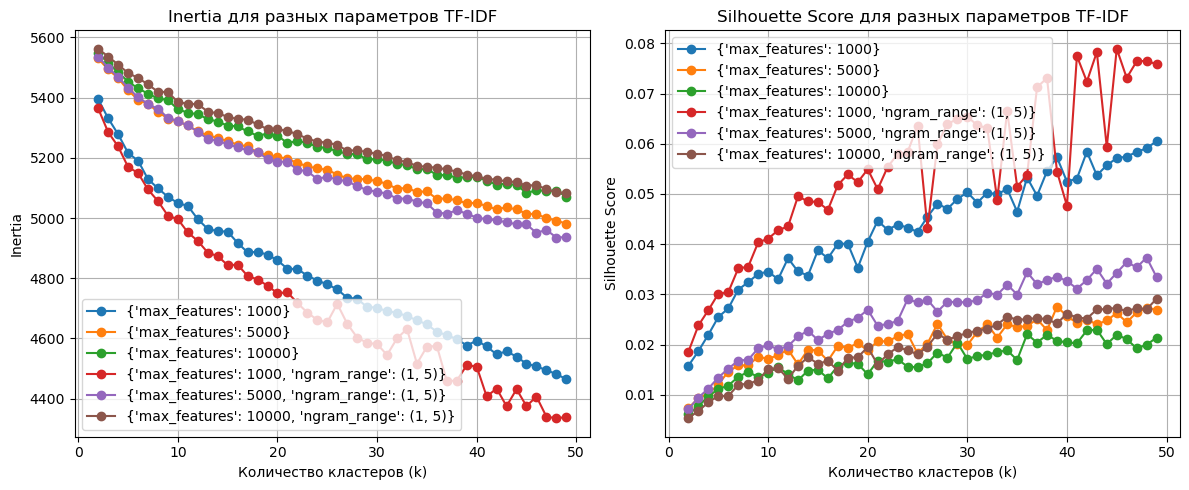

[{'params': {'max_features': 1000},
  'inertias': [5394.669948667839,
   5331.540718360779,
   5278.411754090167,
   5216.310892481961,
   5190.6210759910055,
   5129.3919840337,
   5098.718255005328,
   5070.559202526872,
   5049.693552020738,
   5040.30444609781,
   4996.2314463397115,
   4963.796539284138,
   4956.439645952965,
   4954.870455595288,
   4917.368162811421,
   4886.079152393058,
   4887.702640513227,
   4878.412929432193,
   4859.357701159618,
   4831.557976087287,
   4830.493465495886,
   4808.708434048505,
   4792.448069874851,
   4779.775832281211,
   4763.053375305814,
   4735.123987065298,
   4731.68665365597,
   4704.260252902611,
   4702.620211512713,
   4689.98092168254,
   4685.906949518313,
   4673.808111512044,
   4660.540660375571,
   4646.652868447611,
   4622.389225863193,
   4610.778765273264,
   4598.256103919992,
   4576.38840963159,
   4592.951764558447,
   4573.310943967061,
   4547.040062372532,
   4557.475690383645,
   4539.288436425889,
   4515.91

In [5]:
# Пытаемся определить лучший векторизатор текста путем перебора различных параметров
configs = [
    {"max_features": 1000}, # вариант, хуже дефолтного
    {"max_features": 5000}, # дефолтный вариант
    {"max_features": 10_000}, # улучшенный дефолтный вариант
    {"max_features": 1000, "ngram_range": (1, 5)},
    {"max_features": 5000, "ngram_range": (1, 5)},
    {"max_features": 10000, "ngram_range": (1, 5)},
]

df["clean_event"] = df["event"].str.lower()
results = test_tfidf_configs(df["clean_event"], configs, K=range(2, 50))
results
# Лучший результат показали n_features=1000 с n-граммами (k=48: inertia=4373, silhouette=0.077). Попробуем найти для него подходящее кол-во кластеров
# время выполнения 5m

In [6]:
# мы определили лучший векторизатор, теперь пробуем найти подходящее кол-во кластеров
vectorizer = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 5),
    stop_words=russian_stopwords
)
X = vectorizer.fit_transform(df["event"].str.lower())

find_optimal_k(X, range(2, 200))
# best k=190: inertia=3389, silhouette=0.125. Время выполнения 6m 28s

k=2: inertia=5341, silhouette=0.020
k=3: inertia=5277, silhouette=0.023
k=4: inertia=5230, silhouette=0.026
k=5: inertia=5167, silhouette=0.032
k=6: inertia=5137, silhouette=0.031
k=7: inertia=5115, silhouette=0.033
k=8: inertia=5035, silhouette=0.040
k=9: inertia=5020, silhouette=0.039
k=10: inertia=4994, silhouette=0.041
k=11: inertia=4970, silhouette=0.040
k=12: inertia=4914, silhouette=0.045
k=13: inertia=4901, silhouette=0.046
k=14: inertia=4865, silhouette=0.046
k=15: inertia=4897, silhouette=0.044
k=16: inertia=4861, silhouette=0.048
k=17: inertia=4843, silhouette=0.047
k=18: inertia=4791, silhouette=0.052
k=19: inertia=4781, silhouette=0.053
k=20: inertia=4803, silhouette=0.051
k=21: inertia=4772, silhouette=0.052
k=22: inertia=4739, silhouette=0.055
k=23: inertia=4699, silhouette=0.058
k=24: inertia=4703, silhouette=0.054
k=25: inertia=4662, silhouette=0.059
k=26: inertia=4637, silhouette=0.059
k=27: inertia=4675, silhouette=0.056
k=28: inertia=4666, silhouette=0.053
k=29: ine

{'best_k': 187,
 'best_silhouette': 0.12472010519884881,
 'best_inertia': 3409.477492547192,
 'inertias': [5341.477090991405,
  5277.129239513967,
  5229.626611564394,
  5167.136755557627,
  5136.786443183417,
  5115.180016709165,
  5034.932342493962,
  5020.1700152834055,
  4994.05890499948,
  4970.2820521956655,
  4913.975344559012,
  4901.1939419043065,
  4865.1567104753585,
  4896.757503395416,
  4860.6886441809165,
  4843.304484898625,
  4790.7630586596615,
  4780.589863075328,
  4803.167333899844,
  4771.7589910333945,
  4739.40364017439,
  4698.53410543505,
  4703.297719379856,
  4662.063783869736,
  4637.314193936825,
  4675.221618332943,
  4665.9619638397335,
  4622.775422273089,
  4647.017410564364,
  4646.469118802517,
  4556.6093331827615,
  4586.865053373241,
  4608.161736648477,
  4602.243491271424,
  4559.933156068137,
  4545.151637139488,
  4509.802250790596,
  4449.324204083645,
  4497.196046851077,
  4449.299398940218,
  4501.04510032708,
  4481.457816160833,
  4471.3

In [7]:
# пробуем лучшую модель в действии
k = 190
model = KMeans(n_clusters=k, random_state=42)
df["cluster"] = model.fit_predict(X)

for i in range(k):
    print(f"\n🟢 Кластер {i}")
    examples = df[df["cluster"] == i]["event"].head(10)
    for e in examples:
        print("  -", e)


🟢 Кластер 0
  - В Москве и Мытищах стартовал ежегодный чемпионат мира по хоккею с шайбой. Он продлился до 13 мая.
  - Россия завоевала золото на 72-м чемпионате мира по хоккею с шайбой в канаде.
  - 74-й чемпионат мира по хоккею с шайбой (Германия).
  - В кёльне (германия) состоялся финал 74-го чемпионата мира по хоккею с шайбой. победу одержала сборная чехии.
  - чемпионат мира по хоккею с шайбой (Братислава, Кошице; Словакия). Чемпионом стала сборная Финляндии.
  - Завершился 75-й чемпионат мира по хоккею с шайбой, победу одержала сборная финляндии.
  - чемпионат мира по хоккею с шайбой (Финляндия, Швеция). Победу одержала сборная России.
  - молодёжный чемпионат мира по хоккею c шайбой (Уфа, Россия).
  - 77-й чемпионат мира по хоккею с шайбой (Стокгольм, Швеция и Хельсинки, Финляндия). Сборная Швеции выиграла чемпионат мира в девятый раз.
  - 78-й чемпионат мира по хоккею с шайбой (Минск, Белоруссия) Победу одержала сборная России.

🟢 Кластер 1
  - Сийм Каллас занял пост премьер-ми